# NB03 — Baseline Tabular (LightGBM)

## Objetivo
Treinar e avaliar um classificador binário de adoção rápida vs lenta usando apenas as 50 features tabulares estruturadas. Estabelece um baseline forte e produz a probabilidade `proba_tab` consumida pelo modelo de fusão (NB06).

## Inputs
- `data/processed/X_train_tab.parquet`, `X_val_tab.parquet`, `X_test_tab.parquet`
- `data/processed/splits_index.parquet`

## Outputs
- `results/nb03_baseline_tabular/lightgbm_model.joblib`
- `results/nb03_baseline_tabular/val_predictions.parquet` — `[PetID, y_true, y_proba]`
- `results/nb03_baseline_tabular/test_predictions.parquet` — predictions no test (não usadas para decisões aqui; reservadas para o NB06)
- `results/nb03_baseline_tabular/metrics.json` — accuracy, precision, recall, F1, ROC-AUC, PR-AUC em validação
- `results/nb03_baseline_tabular/shap_values_val.parquet` — valores SHAP por feature por animal
- `results/nb03_baseline_tabular/feature_importance_shap.parquet` — ranking agregado

## Decisões metodológicas
- LightGBM com `early_stopping` em validação para escolher número ótimo de árvores
- Métricas reportadas em validação; test reservado para avaliação final no NB06
- Importâncias via SHAP (não `gain` ou `split`) para separar o efeito de features confundidas (ex: `Sterilized` × `Age`)

In [1]:
# =============================================================================
# NB03 — Baseline Tabular (LightGBM)
# Célula 1: Imports e verificação do ambiente
# =============================================================================

# Bibliotecas standard de data science
import numpy as np
import pandas as pd
from pathlib import Path
import json
import joblib

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
import lightgbm as lgb

# Métricas de avaliação (classificação binária)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

# Interpretabilidade
import shap

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -----------------------------------------------------------------------------
# Verificação de versões — útil se algo partir no futuro
# -----------------------------------------------------------------------------
print("Versões instaladas:")
print(f"  numpy        : {np.__version__}")
print(f"  pandas       : {pd.__version__}")
print(f"  lightgbm     : {lgb.__version__}")
print(f"  shap         : {shap.__version__}")

# -----------------------------------------------------------------------------
# Paths do projeto — assume que o notebook está em notebooks/
# -----------------------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"\nPROJECT_ROOT    : {PROJECT_ROOT}")
print(f"DATA_PROCESSED  : {DATA_PROCESSED}")
print(f"RESULTS_DIR     : {RESULTS_DIR}")

# Confirmar que os artefactos do NB02 existem
required_files = [
    "splits_index.parquet",
    "X_train_tab.parquet",
    "X_val_tab.parquet",
    "X_test_tab.parquet",
    "standard_scaler.joblib",
    "preprocessing_metadata.json",
]

print("\nArtefactos do NB02:")
for f in required_files:
    path = DATA_PROCESSED / f
    status = "✅" if path.exists() else "❌ EM FALTA"
    print(f"  {status}  {f}")
    

Versões instaladas:
  numpy        : 2.4.4
  pandas       : 3.0.2
  lightgbm     : 4.6.0
  shap         : 0.51.0

PROJECT_ROOT    : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder
DATA_PROCESSED  : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/data/processed
RESULTS_DIR     : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results

Artefactos do NB02:
  ✅  splits_index.parquet
  ✅  X_train_tab.parquet
  ✅  X_val_tab.parquet
  ✅  X_test_tab.parquet
  ✅  standard_scaler.joblib
  ✅  preprocessing_metadata.json


In [ ]:
# =============================================================================
# Célula 2: Carregamento dos artefactos do NB02
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Splits index — mapa central (PetID → split, y, RescuerID)
# -----------------------------------------------------------------------------
splits_index = pd.read_parquet(DATA_PROCESSED / "splits_index.parquet")

print("splits_index")
print(f"  shape   : {splits_index.shape}")
print(f"  colunas : {list(splits_index.columns)}")
print(f"  dtypes  :\n{splits_index.dtypes}")
print()
print("Primeiras 5 linhas:")
print(splits_index.head())

# -----------------------------------------------------------------------------
# 2. Distribuição dos splits
# -----------------------------------------------------------------------------
print("\nDistribuição dos splits:")
split_counts = splits_index["split"].value_counts()
split_pct = splits_index["split"].value_counts(normalize=True) * 100
for split_name in ["train", "val", "test"]:
    n = split_counts[split_name]
    pct = split_pct[split_name]
    print(f"  {split_name:5s} : {n:>5} ({pct:.1f}%)")

# -----------------------------------------------------------------------------
# 3. Balanceamento do target em cada split
# -----------------------------------------------------------------------------
print("\nBalanceamento do target (y=1 → adoção rápida):")
for split_name in ["train", "val", "test"]:
    subset = splits_index[splits_index["split"] == split_name]
    pct_positive = subset["y"].mean() * 100
    print(f"  {split_name:5s} : {pct_positive:.2f}% positivos")

# -----------------------------------------------------------------------------
# 4. Matrizes X
# -----------------------------------------------------------------------------
X_train = pd.read_parquet(DATA_PROCESSED / "X_train_tab.parquet")
X_val   = pd.read_parquet(DATA_PROCESSED / "X_val_tab.parquet")
X_test  = pd.read_parquet(DATA_PROCESSED / "X_test_tab.parquet")

print("\nMatrizes X carregadas:")
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")

# -----------------------------------------------------------------------------
# 5. Sanity check: as três matrizes têm as mesmas colunas?
# -----------------------------------------------------------------------------
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), \
    "ERRO: as colunas não coincidem entre splits!"

# -----------------------------------------------------------------------------
# 6. Metadata do preprocessing
# -----------------------------------------------------------------------------
with open(DATA_PROCESSED / "preprocessing_metadata.json", "r") as f:
    preprocessing_metadata = json.load(f)

print(f"\nMetadata do NB02 carregado — chaves disponíveis:")
for key in preprocessing_metadata.keys():
    print(f"  • {key}")
    

splits_index
  shape   : (14993, 4)
  colunas : ['PetID', 'split', 'y', 'RescuerID']
  dtypes  :
PetID          str
split          str
y            int64
RescuerID      str
dtype: object

Primeiras 5 linhas:
       PetID  split  y                         RescuerID
0  6296e909a  train  1  3082c7125d8fb66f7dd4bff4192c8b14
1  5842f1ff5  train  1  9238e4f44c71a75282e62f7136c6b240
2  850a43f90  train  1  95481e953f8aed9ec3d16fc4509537e8
3  d24c30b4b  train  1  22fe332bf9c924d4718005891c63fbed
4  1caa6fcdb  train  1  1e0b5a458b5b77f5af581d57ebf570b3

Distribuição dos splits:
  train :  9600 (64.0%)
  val   :  2396 (16.0%)
  test  :  2997 (20.0%)

Balanceamento do target (y=1 → adoção rápida):
  train : 50.27% positivos
  val   : 50.29% positivos
  test  : 50.25% positivos

Matrizes X carregadas:
  X_train : (9600, 51)
  X_val   : (2396, 51)
  X_test  : (2997, 51)

Metadata do NB02 carregado — chaves disponíveis:
  • random_seed
  • numeric_cols_scaled
  • top20_breeds
  • top3_states
  • mix

In [ ]:
# =============================================================================
# Célula 3: Preparar X e y alinhados para treino
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Função helper
# -----------------------------------------------------------------------------
def align_X_y(X_df: pd.DataFrame, splits_idx: pd.DataFrame, split_name: str):
    """
    Alinha uma matriz X com o target y, garantindo correspondência por PetID.

    Parâmetros
    ----------
    X_df : DataFrame com coluna 'PetID' + features
    splits_idx : DataFrame com ['PetID', 'split', 'y', 'RescuerID']
    split_name : 'train', 'val' ou 'test' — para filtrar e validar

    Retorna
    -------
    X_arr : numpy array (n_samples, n_features) — só features, sem PetID
    y_arr : numpy array (n_samples,) — target binário
    feature_names : list[str] — nomes das features, na ordem das colunas de X_arr
    pet_ids : numpy array (n_samples,) — PetIDs preservados para referência
    """
    # Filtrar o splits_index para este split apenas
    split_subset = splits_idx[splits_idx["split"] == split_name][["PetID", "y"]]

    # Merge por PetID — garante alinhamento correto
    merged = X_df.merge(split_subset, on="PetID", how="inner")

    # Validação: o número de linhas deve bater com o X original
    assert len(merged) == len(X_df), (
        f"ERRO no split '{split_name}': merge perdeu linhas "
        f"(X={len(X_df)}, merged={len(merged)})"
    )

    # Separar
    pet_ids = merged["PetID"].values
    y_arr = merged["y"].values
    feature_names = [c for c in merged.columns if c not in ("PetID", "y")]
    X_arr = merged[feature_names].values

    return X_arr, y_arr, feature_names, pet_ids


# -----------------------------------------------------------------------------
# 2. Aplicar aos três splits
# -----------------------------------------------------------------------------
X_train_arr, y_train, feature_names, pet_ids_train = align_X_y(X_train, splits_index, "train")
X_val_arr,   y_val,   _,             pet_ids_val   = align_X_y(X_val,   splits_index, "val")
X_test_arr,  y_test,  _,             pet_ids_test  = align_X_y(X_test,  splits_index, "test")

# -----------------------------------------------------------------------------
# 3. Verificação final
# -----------------------------------------------------------------------------
print("Shapes finais:")
print(f"  X_train : {X_train_arr.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val_arr.shape}   y_val   : {y_val.shape}")
print(f"  X_test  : {X_test_arr.shape}   y_test  : {y_test.shape}")

print(f"\nNúmero de features : {len(feature_names)}")
print(f"Tipo de X_train_arr : {X_train_arr.dtype}")
print(f"Tipo de y_train     : {y_train.dtype}")

print(f"\nBalanceamento após alinhamento:")
print(f"  train : {y_train.mean()*100:.2f}% positivos")
print(f"  val   : {y_val.mean()*100:.2f}% positivos")
print(f"  test  : {y_test.mean()*100:.2f}% positivos")

print(f"\nPrimeiras 10 features:")
for i, name in enumerate(feature_names[:10]):
    print(f"  {i:2d}. {name}")
print(f"  ... (mais {len(feature_names) - 10} features)")

Shapes finais:
  X_train : (9600, 50)   y_train : (9600,)
  X_val   : (2396, 50)   y_val   : (2396,)
  X_test  : (2997, 50)   y_test  : (2997,)

Número de features : 50
Tipo de X_train_arr : float64
Tipo de y_train     : int64

Balanceamento após alinhamento:
  train : 50.27% positivos
  val   : 50.29% positivos
  test  : 50.25% positivos

Primeiras 10 features:
   0. Type
   1. Gender
   2. Color2
   3. Color3
   4. MaturitySize
   5. FurLength
   6. Vaccinated
   7. Dewormed
   8. Sterilized
   9. Health
  ... (mais 40 features)


In [4]:
# =============================================================================
# Célula 4: Treinar LightGBM com early stopping no validation set
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Converter os dados para o formato nativo do LightGBM (Dataset)
# -----------------------------------------------------------------------------
# O LightGBM tem o seu próprio formato interno, que é mais eficiente que
# passar arrays numpy diretamente. Mantemos os feature_names para SHAP depois.

lgb_train = lgb.Dataset(
    X_train_arr,
    label=y_train,
    feature_name=feature_names,
)

lgb_val = lgb.Dataset(
    X_val_arr,
    label=y_val,
    feature_name=feature_names,
    reference=lgb_train,  # diz ao LightGBM que é o "mesmo esquema" do train
)

# -----------------------------------------------------------------------------
# 2. Definir hiperparâmetros
# -----------------------------------------------------------------------------
params = {
    "objective": "binary",          # classificação binária
    "metric": "binary_logloss",     # função monitorizada para early stopping
    "learning_rate": 0.05,          # passo de correção de cada árvore
    "num_leaves": 31,               # complexidade de cada árvore (default)
    "min_child_samples": 20,        # mínimo de amostras por folha
    "feature_fraction": 0.9,        # cada árvore vê 90% das features (regularização)
    "bagging_fraction": 0.9,        # cada árvore vê 90% das linhas (regularização)
    "bagging_freq": 5,              # aplica bagging a cada 5 iterações
    "verbose": -1,                  # silenciar output interno
    "random_state": RANDOM_STATE,
}

# -----------------------------------------------------------------------------
# 3. Treinar com early stopping
# -----------------------------------------------------------------------------
print("A treinar LightGBM...\n")

model = lgb.train(
    params=params,
    train_set=lgb_train,
    num_boost_round=2000,                    # máximo de árvores
    valid_sets=[lgb_train, lgb_val],         # monitorizar train e val
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),   # parar se val não melhorar em 100 rounds
        lgb.log_evaluation(period=50),             # imprimir loss a cada 50 árvores
    ],
)

# -----------------------------------------------------------------------------
# 4. Relatório de treino
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("Treino concluído.")
print(f"  Melhor iteração          : {model.best_iteration}")
print(f"  Número final de árvores  : {model.best_iteration}")
print(f"  Best val logloss         : {model.best_score['val']['binary_logloss']:.4f}")
print(f"  Best train logloss       : {model.best_score['train']['binary_logloss']:.4f}")
print("=" * 60)

A treinar LightGBM...

Training until validation scores don't improve for 100 rounds
[50]	train's binary_logloss: 0.596194	val's binary_logloss: 0.645214
[100]	train's binary_logloss: 0.56744	val's binary_logloss: 0.644504
[150]	train's binary_logloss: 0.545377	val's binary_logloss: 0.646484
Early stopping, best iteration is:
[84]	train's binary_logloss: 0.575373	val's binary_logloss: 0.644298

Treino concluído.
  Melhor iteração          : 84
  Número final de árvores  : 84
  Best val logloss         : 0.6443
  Best train logloss       : 0.5754


Previsões geradas no val com threshold=0.5
  Distribuição previsões : {1: 1248, 0: 1148}
  Distribuição real      : {1: 1205, 0: 1191}

Métricas no validation set
  accuracy     : 0.6215
  precision    : 0.6194
  recall       : 0.6415
  f1           : 0.6302
  roc_auc      : 0.6758
  pr_auc       : 0.6516

Classification report:
                   precision    recall  f1-score   support

 Adoção Lenta (0)     0.6237    0.6012    0.6122      1191
Adoção Rápida (1)     0.6194    0.6415    0.6302      1205

         accuracy                         0.6215      2396
        macro avg     0.6215    0.6213    0.6212      2396
     weighted avg     0.6215    0.6215    0.6213      2396



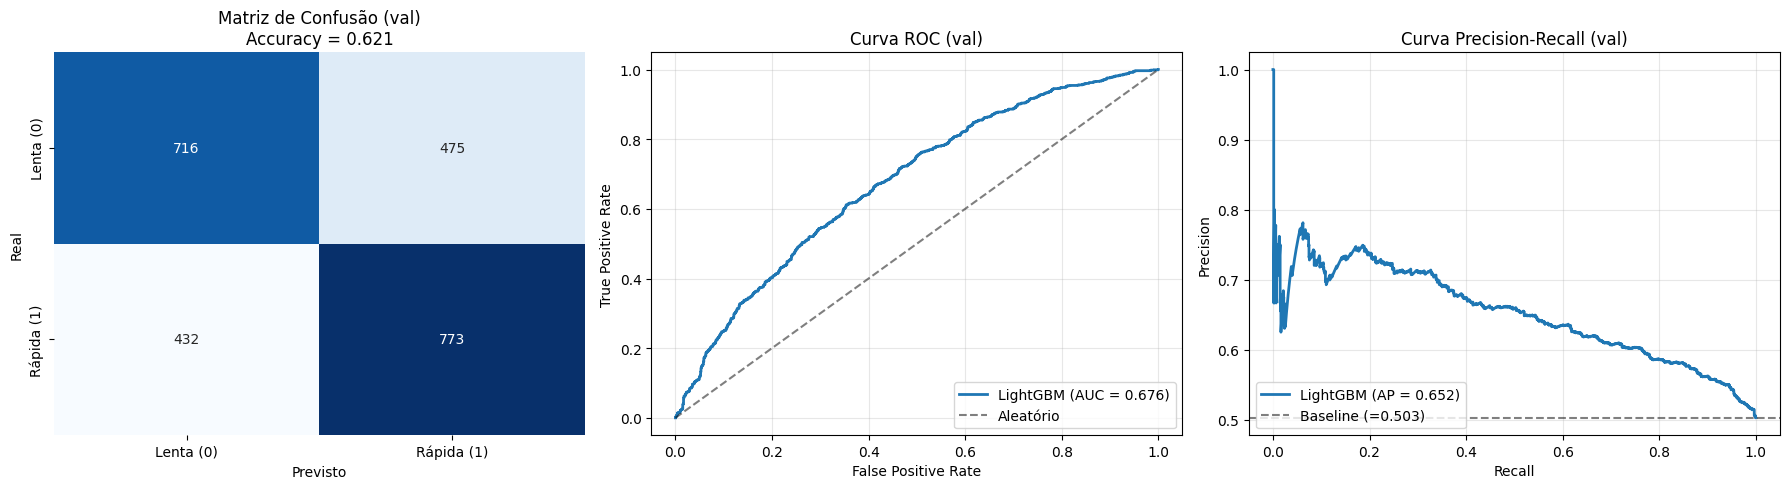

In [5]:
# =============================================================================
# Célula 5: Avaliação no validation set
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Gerar previsões no val
# -----------------------------------------------------------------------------
# predict() devolve probabilidades (valores entre 0 e 1)
# Usamos num_iteration=best_iteration para usar só as 84 melhores árvores
y_val_proba = model.predict(X_val_arr, num_iteration=model.best_iteration)

# Converter probabilidades em labels binárias com threshold 0.5
THRESHOLD = 0.5
y_val_pred = (y_val_proba >= THRESHOLD).astype(int)

print(f"Previsões geradas no val com threshold={THRESHOLD}")
print(f"  Distribuição previsões : {pd.Series(y_val_pred).value_counts().to_dict()}")
print(f"  Distribuição real      : {pd.Series(y_val).value_counts().to_dict()}")

# -----------------------------------------------------------------------------
# 2. Calcular métricas
# -----------------------------------------------------------------------------
metrics = {
    "accuracy":    accuracy_score(y_val, y_val_pred),
    "precision":   precision_score(y_val, y_val_pred),
    "recall":      recall_score(y_val, y_val_pred),
    "f1":          f1_score(y_val, y_val_pred),
    "roc_auc":     roc_auc_score(y_val, y_val_proba),
    "pr_auc":      average_precision_score(y_val, y_val_proba),
}

print("\n" + "=" * 50)
print("Métricas no validation set")
print("=" * 50)
for name, value in metrics.items():
    print(f"  {name:12s} : {value:.4f}")
print("=" * 50)

# Relatório detalhado por classe
print("\nClassification report:")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=["Adoção Lenta (0)", "Adoção Rápida (1)"],
    digits=4,
))

# -----------------------------------------------------------------------------
# 3. Matriz de confusão + curvas ROC e PR (três gráficos lado a lado)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 3a. Matriz de confusão ---
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Lenta (0)", "Rápida (1)"],
    yticklabels=["Lenta (0)", "Rápida (1)"],
    ax=axes[0],
)
axes[0].set_xlabel("Previsto")
axes[0].set_ylabel("Real")
axes[0].set_title(f"Matriz de Confusão (val)\nAccuracy = {metrics['accuracy']:.3f}")

# --- 3b. Curva ROC ---
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
axes[1].plot(fpr, tpr, label=f"LightGBM (AUC = {metrics['roc_auc']:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aleatório")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC (val)")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

# --- 3c. Curva Precision-Recall ---
precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_val_proba)
axes[2].plot(recall_curve, precision_curve, label=f"LightGBM (AP = {metrics['pr_auc']:.3f})", linewidth=2)
axes[2].axhline(y=y_val.mean(), color="k", linestyle="--", alpha=0.5, label=f"Baseline (={y_val.mean():.3f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Curva Precision-Recall (val)")
axes[2].legend(loc="lower left")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

A criar TreeExplainer...
A calcular SHAP values no validation set...
SHAP values shape : (2396, 50)
  → 2396 animais × 50 features

📊 SHAP Summary Plot (beeswarm):
  • Eixo X: impacto na previsão (positivo = empurra para 'Adoção Rápida')
  • Cor vermelha: valor alto da feature
  • Cor azul: valor baixo da feature
  • Cada ponto é um animal do validation set



/opt/anaconda3/envs/petfinder/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/var/folders/jy/4lj4gvfs15j22x8x1xygrbfm0000gn/T/ipykernel_19350/2371447118.py:39: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


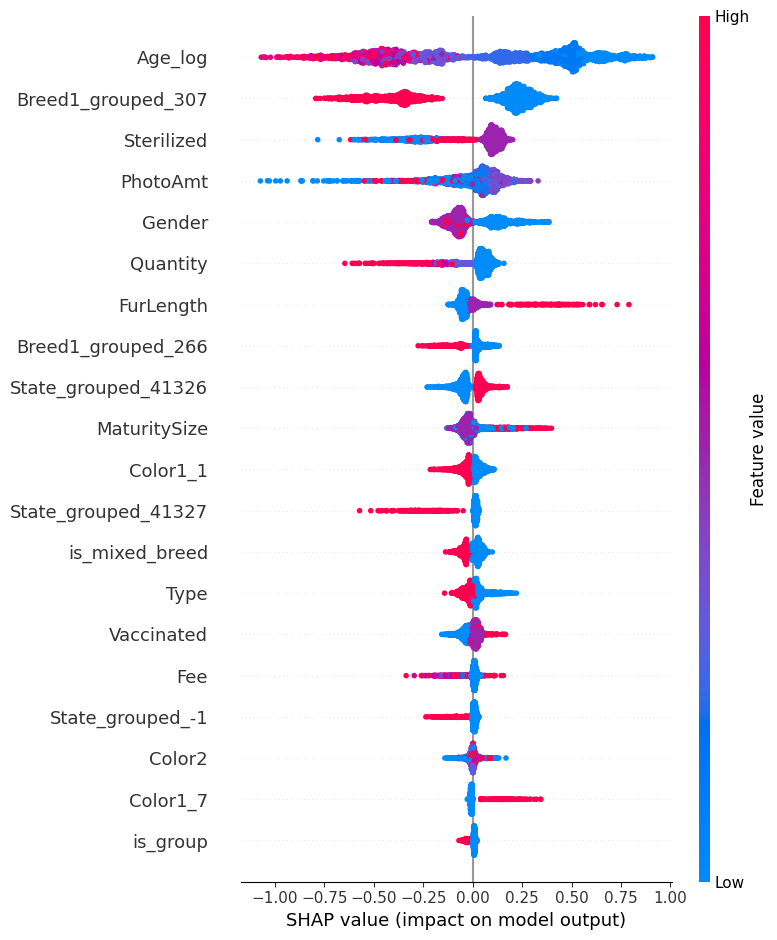


📊 SHAP Bar Plot (importância média):


/var/folders/jy/4lj4gvfs15j22x8x1xygrbfm0000gn/T/ipykernel_19350/2371447118.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


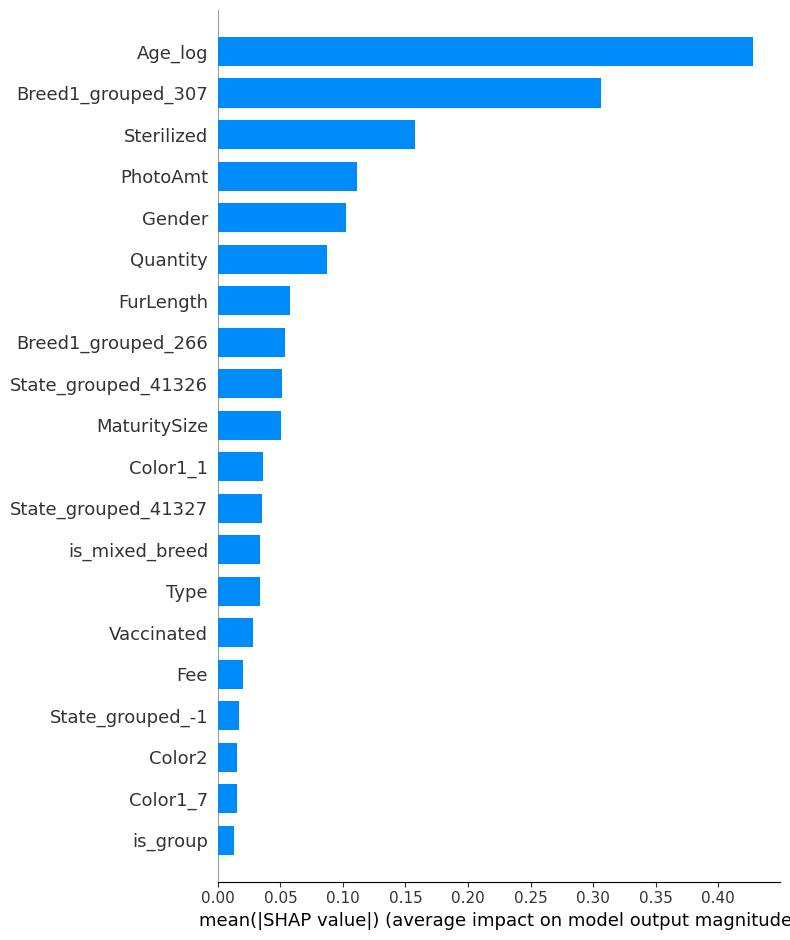


Top 15 features por importância SHAP média:
            feature  mean_abs_shap
            Age_log       0.428032
 Breed1_grouped_307       0.306671
         Sterilized       0.157380
           PhotoAmt       0.111510
             Gender       0.102678
           Quantity       0.087131
          FurLength       0.057352
 Breed1_grouped_266       0.053312
State_grouped_41326       0.051342
       MaturitySize       0.050191
           Color1_1       0.036094
State_grouped_41327       0.034957
     is_mixed_breed       0.033969
               Type       0.033884
         Vaccinated       0.028261


In [ ]:
# =============================================================================
# Célula 6: Interpretabilidade com SHAP
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Criar o explainer — otimizado para modelos baseados em árvores
# -----------------------------------------------------------------------------
print("A criar TreeExplainer...")
explainer = shap.TreeExplainer(model)

# -----------------------------------------------------------------------------
# 2. Calcular SHAP values no val
# -----------------------------------------------------------------------------
# Calculado no val (não no train) porque:
# - É o conjunto em que avaliámos o modelo
# - O train pode sobre-estimar importâncias por overfitting
# - 2396 linhas são suficientes para uma visão estatisticamente estável
print("A calcular SHAP values no validation set...")
shap_values = explainer.shap_values(X_val_arr)

# Em classificação binária, algumas versões do SHAP devolvem uma lista
# [shap_class_0, shap_class_1]. Outras devolvem um array único com a classe
# positiva. Normalização feita aqui.
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # classe positiva (adoção rápida)

print(f"SHAP values shape : {shap_values.shape}")
print(f"  → {shap_values.shape[0]} animais × {shap_values.shape[1]} features")

# -----------------------------------------------------------------------------
# 3. Summary plot — o gráfico mais informativo
# -----------------------------------------------------------------------------
print("\n📊 SHAP Summary Plot (beeswarm):")
print("  • Eixo X: impacto na previsão (positivo = empurra para 'Adoção Rápida')")
print("  • Cor vermelha: valor alto da feature")
print("  • Cor azul: valor baixo da feature")
print("  • Cada ponto é um animal do validation set\n")

shap.summary_plot(
    shap_values,
    X_val_arr,
    feature_names=feature_names,
    max_display=20,          # top 20 features
    show=True,
)

# -----------------------------------------------------------------------------
# 4. Bar plot: ranking puro de importância 
# -----------------------------------------------------------------------------
print("\n📊 SHAP Bar Plot (importância média):")
shap.summary_plot(
    shap_values,
    X_val_arr,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=True,
)

# -----------------------------------------------------------------------------
# 5. Top features numericamente
# -----------------------------------------------------------------------------
importance_mean_abs = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": importance_mean_abs,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nTop 15 features por importância SHAP média:")
print(importance_df.head(15).to_string(index=False))

In [ ]:
# =============================================================================
# Célula 7: Persistência de artefactos
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Criar subpasta para artefactos do NB03
# -----------------------------------------------------------------------------
NB03_DIR = RESULTS_DIR / "nb03_baseline_tabular"
NB03_DIR.mkdir(exist_ok=True)
print(f"Diretório de artefactos: {NB03_DIR}\n")

# -----------------------------------------------------------------------------
# 2. Guardar o modelo LightGBM (formato nativo)
# -----------------------------------------------------------------------------
model_path = NB03_DIR / "lightgbm_baseline.txt"
model.save_model(
    str(model_path),
    num_iteration=model.best_iteration,  # guardar só as 84 melhores árvores
)
print(f"   Árvores: {model.best_iteration}")

# -----------------------------------------------------------------------------
# 3. Gerar previsões no test (sem olhar para as métricas!)
# -----------------------------------------------------------------------------
y_test_proba = model.predict(X_test_arr, num_iteration=model.best_iteration)
print(f"   ⚠️  NÃO serão calculadas métricas no test aqui, apenas mais no notebook multimodal.")

# -----------------------------------------------------------------------------
# 4. Guardar previsões (val e test)
# -----------------------------------------------------------------------------
val_predictions = pd.DataFrame({
    "PetID":      pet_ids_val,
    "y_true":     y_val,
    "y_proba":    y_val_proba,
    "y_pred":     y_val_pred,
})
val_predictions.to_parquet(NB03_DIR / "val_predictions.parquet", index=False)

test_predictions = pd.DataFrame({
    "PetID":   pet_ids_test,
    "y_true":  y_test,
    "y_proba": y_test_proba,
})
test_predictions.to_parquet(NB03_DIR / "test_predictions.parquet", index=False)

# -----------------------------------------------------------------------------
# 5. Guardar métricas do val
# -----------------------------------------------------------------------------
metrics_report = {
    "model": "LightGBM",
    "modality": "tabular",
    "n_features": len(feature_names),
    "n_trees": int(model.best_iteration),
    "hyperparameters": params,
    "val_metrics": {k: float(v) for k, v in metrics.items()},
    "val_confusion_matrix": {
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    },
    "threshold_used": THRESHOLD,
    "best_val_logloss": float(model.best_score["val"]["binary_logloss"]),
    "best_train_logloss": float(model.best_score["train"]["binary_logloss"]),
}

with open(NB03_DIR / "metrics.json", "w") as f:
    json.dump(metrics_report, f, indent=2)

# -----------------------------------------------------------------------------
# 6. Guardar SHAP values + tabela de importâncias
# -----------------------------------------------------------------------------
shap_df = pd.DataFrame(shap_values, columns=feature_names)
shap_df.insert(0, "PetID", pet_ids_val)
shap_df.to_parquet(NB03_DIR / "shap_values_val.parquet", index=False)

# Tabela resumo de importâncias
importance_df.to_parquet(NB03_DIR / "feature_importance_shap.parquet", index=False)

# -----------------------------------------------------------------------------
# 7. Sumário final do notebook
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("NB03 concluído — resumo:")
print("=" * 60)
print(f"  Modelo              : LightGBM ({model.best_iteration} árvores)")
print(f"  Features usadas     : {len(feature_names)}")
print(f"  Val accuracy        : {metrics['accuracy']:.4f}")
print(f"  Val F1              : {metrics['f1']:.4f}")
print(f"  Val ROC-AUC         : {metrics['roc_auc']:.4f}  ← baseline a bater")
print(f"  Val PR-AUC          : {metrics['pr_auc']:.4f}")
print(f"\n  Top 3 features SHAP : {', '.join(importance_df['feature'].head(3).tolist())}")
print(f"\n  Artefactos em       : results/nb03_baseline_tabular/")
print("=" * 60)


Diretório de artefactos: /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb03_baseline_tabular

   Árvores: 84
   ⚠️  NÃO serão calculadas métricas no test aqui, apenas mais no notebook multimodal.

NB03 concluído — resumo:
  Modelo              : LightGBM (84 árvores)
  Features usadas     : 50
  Val accuracy        : 0.6215
  Val F1              : 0.6302
  Val ROC-AUC         : 0.6758  ← baseline a bater
  Val PR-AUC          : 0.6516

  Top 3 features SHAP : Age_log, Breed1_grouped_307, Sterilized

  Artefactos em       : results/nb03_baseline_tabular/


## Sumário do NB03

**Modelo oficial:** LightGBM com early stopping em validação

**Métricas em validação:**
- ROC-AUC: 0.6758
- F1 (threshold 0.5): ver `metrics.json`
- PR-AUC: ver `metrics.json`

**Top features (SHAP):**
1. `PhotoAmt` — número de fotografias
2. `Age_log` — idade transformada por log
3. `Type` — espécie (cão/gato)

**Para o NB06:**
- Usar `val_predictions.parquet[y_proba]` como feature `proba_tab` do modelo de fusão
- **Não** usar `y_pred` para decisões: threshold final é decidido após fusão
- `test_predictions.parquet` está disponível mas não foi usado para escolhas aqui (test reservado para avaliação final no NB06)